In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xndc4\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
assassin = pd.read_csv('spam_csvs/Assassin.csv')
assassin_filtered = assassin[['subject', 'body', 'label']]
ceas_08 = pd.read_csv('spam_csvs/CEAS-08.csv')
ceas_08_filtered = ceas_08[['subject', 'body', 'label']]
enron = pd.read_csv('spam_csvs/Enron.csv')
enron_filtered = enron[['subject', 'body', 'label']]
ling = pd.read_csv('spam_csvs/Ling.csv')
ling_filtered = ling[['subject', 'body', 'label']]
trec_05 = pd.read_csv('spam_csvs/TREC-05.csv', encoding='latin1')
trec_05_filtered = trec_05[['subject', 'body', 'label']]
trec_06 = pd.read_csv('spam_csvs/TREC-06.csv', encoding='latin1')
trec_06_filtered = trec_06[['subject', 'body', 'label']]
trec_07 = pd.read_csv('spam_csvs/TREC-07.csv', encoding='latin1')
trec_07_filtered = trec_07[['subject', 'body', 'label']]

data = pd.concat([assassin_filtered, ceas_08_filtered, enron_filtered, ling_filtered, trec_05_filtered, trec_06_filtered, trec_07_filtered], ignore_index=True)
data.head()

,subject,body,label
0,Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0
1,[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0
2,[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0
3,[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0
4,Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0


In [20]:
data.shape

(263606, 3)

In [22]:
data_cleaned = data.dropna(how='any')
data_cleaned.shape

(201581, 3)

In [24]:
label_cleaned = data_cleaned[data_cleaned['label'].isin([0, 1])]
label_cleaned.shape

(157362, 3)

In [47]:
count_0 = np.sum(label_cleaned == 0)
count_1 = np.sum(label_cleaned == 1)

print(f"Number of 0s: {count_0}")
print(f"Number of 1s: {count_1}")

Number of 0s: subject        0
body           0
label      82654
dtype: int64
Number of 1s: subject        0
body           0
label      74708
dtype: int64


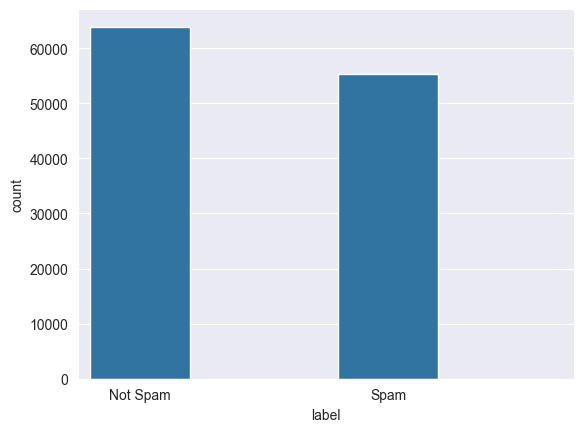

In [63]:
sns.countplot(x='label', data=label_cleaned)
plt.xticks(ticks=[0, 2], labels=['Not Spam', 'Spam'])
plt.show()

In [48]:
ham_msg = label_cleaned[label_cleaned['label'] == 0]
spam_msg = label_cleaned[label_cleaned['label'] == 1]

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

In [50]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['subject'] = balanced_data['subject'].apply(lambda text: remove_stopwords(text))
balanced_data['body'] = balanced_data['body'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,subject,body,label
0,re: renewable energy product description,comments awesome. probably asked write thing f...,0.0
1,start date : 1 / 6 / 02 ; hourahead hour : 7 ;,start date : 1 / 6 / 02 ; hourahead hour : 7 ;...,0
2,fw: strawnie,fyi -----original message----- from: sally wil...,0.0
3,municipal utilities,"attached, please find electronic version mater...",0.0
4,[dmdx] script help: visual search cueing,"trying dmdx first time, looking helpful resour...",0


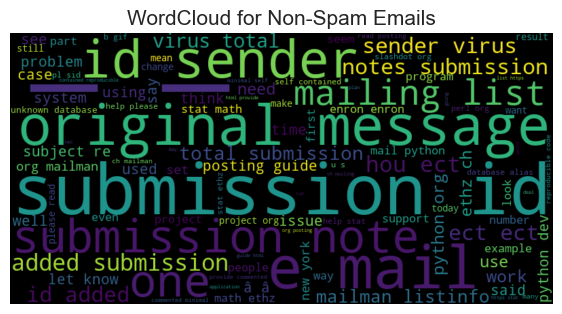

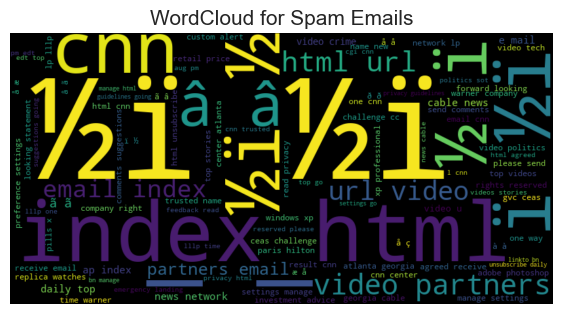

In [57]:
def plot_word_cloud(data, typ):
    email_corpus = (data['subject'].astype(str) + ' ' + data['body'].astype(str)).str.cat(sep=' ')
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 0], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 1], typ='Spam')

In [58]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['subject'] + ' ' + balanced_data['body'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')


In [64]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
  89/3736 ━━━━━━━━━━━━━━━━━━━━ 4:21 72ms/step - accuracy: 0.9362 - loss: 0.4801

In [61]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 1.4208e-06
Test Loss : 1.4180258176565985e-06
Test Accuracy : 1.0


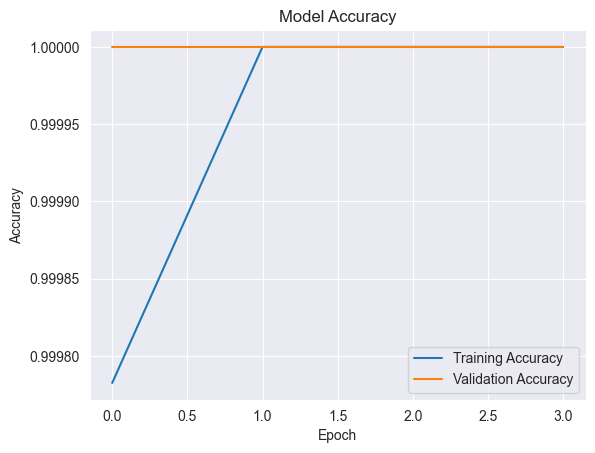

In [62]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()